In [48]:
import numpy as np
import pandas as pd

In [28]:
from google.colab import files
# Prompt user to upload file
uploaded = files.upload()


Saving datset_timing_violation.xlsx to datset_timing_violation (1).xlsx


 **Original DataSet**

In [49]:
df = pd.read_excel('datset_timing_violation.xlsx')
display(df)

,model_complexity,"[fan_in,fan_out,log_depth]",Gates labels,clock_count,clock_time_period,clcok_skew,clock_gitter,input_delay,output_delay,setup_slack,hold_slack,violation
0,"[\n [0, 0, 1, 0],\n [0, 0, 1, 1],\n [...","[\n [1, 1, 1],\n [2, 1, 1],\n [2, 1, ...","[not,nand,nand,reg]",1,10,1.00,0.200,2.00,2.50,2.20,2.43,0
1,"[\n [0, 0, 1, 0],\n [0, 0, 1, 0],\n [...","[\n [1, 1, 1],\n [2, 1, 1],\n [2, 1, ...","[not,nand,nand,reg]",1,2,0.80,0.100,3.00,4.50,-3.70,4.53,1
2,"[\n [0, 0, 1, 0],\n [0, 0, 1, 0],\n [...","[\n [1, 1, 1],\n [2, 1, 1],\n [2, 1, ...","[not,nand,nand,reg]",1,5,-0.80,0.340,6.00,8.90,-6.84,8.69,1
3,"[\n [0, 0, 1, 0],\n [0, 0, 1, 0],\n [...","[\n [1, 1, 1],\n [2, 1, 1],\n [2, 1, ...","[not,nand,nand,reg]",1,20,0.60,0.150,1.00,4.00,5.75,3.98,0
4,"[\n [0, 1],\n [0, 0]\n]\n","[\n [2, 1,0],\n [2, 1,0]\n]","\n[dff,dff]",2,13,0.58,0.030,0.70,2.00,10.73,0.22,0
...,...,...,...,...,...,...,...,...,...,...,...,...
111,"[\n [0, 1, 0, 0], \n [0, 0, 1, 0], \n ...","[\n [4, 1, 0],\n [2, 1, 1],\n [2, 1, ...","[srff,and,xor,dff]",1,18,1.73,0.176,-2.30,-1.13,16.08,-2.39,1
112,"[ \n [0, 0, 1, 1, 1, 0, 0], \n [0, 0, ...","[\n [3, 1, 0],\n [3, 1, 0],\n [2, 1, ...","[dff, dff, and, xor, xor, add, dff]",3,20,-1.87,0.030,-2.56,-3.47,18.62,-3.37,1
113,"[ \n [0, 0, 1, 1, 1, 0, 0], \n [0, 0, ...","[\n [3, 1, 0],\n [3, 1, 0],\n [2, 1, ...","[dff, dff, and, xor, xor, add, dff]",3,11,0.27,0.270,1.86,4.28,6.22,0.16,0
114,"[ \n [0, 0, 1, 1, 1, 0, 0], \n [0, 0, ...","[\n [3, 1, 0],\n [3, 1, 0],\n [2, 1, ...","[dff, dff, and, xor, xor, add, dff]",3,6,-2.09,0.140,2.94,-4.19,2.63,-4.20,1


In [50]:
type(df['model_complexity'][0])


str

**converting matrix(string format) into lists**


In [51]:
import ast
# Convert string to actual list of lists
df['model_complexity'] = df['model_complexity'].apply(ast.literal_eval) # dataframe has list of lists in string fromat so converting into list

In [52]:
df['[fan_in,fan_out,log_depth]'] = df['[fan_in,fan_out,log_depth]'].apply(ast.literal_eval)


In [53]:
import re
import ast

def fix_and_eval_label_string(label_str):
    try:
        # Add quotes around words like: [not, nand, reg] → ['not', 'nand', 'reg']
        fixed_str = re.sub(r'(\w+)', r'"\1"', label_str)
        return ast.literal_eval(fixed_str)
    except:
        return []  # fallback for malformed data

df['Gates labels'] = df['Gates labels'].apply(fix_and_eval_label_string)
## we have gate labels has [not,nand,nand,reg] like this , so inner words are not considerd as string so we need like ["not","nand","nand","reg"]

In [54]:
df['Gates labels'][1]

['not', 'nand', 'nand', 'reg']

**encoding of gates and adding them as a node feature to previous column**

as the gate values are not in order , it should follow the one hot encoding , but we are not using distance based alg's like linear or logistic regression  so , its okay to go with label encoding

In [55]:
# we are adding gate lables to a node features in previous column
# Sample mapping dictionary
label_map = {
    'and': 0,
    'or': 1,
    'nand': 2,
    'xor': 4,
    'nor': 3,
    'not': 5,
    'dff': 6,
    'reg':6,
    'srff':7,
    'tff':8,
    'jff':9,
    'add':10,
    'sub':11

}

# Function to combine fan_in row and mapped label
def append_label_to_fanin(fanin_row, labels_row):
    result = []
    for features, label in zip(fanin_row, labels_row):
        mapped_label = label_map.get(label.lower(), -1)  # -1 for unknowns
        result.append(features + [mapped_label])
    return result

# Apply to create new column
df['features_with_gate_encodings'] = df.apply(lambda row: append_label_to_fanin(row['[fan_in,fan_out,log_depth]'], row['Gates labels']), axis=1)

In [56]:
df.features_with_gate_encodings

,features_with_gate_encodings
0,"[[1, 1, 1, 5], [2, 1, 1, 2], [2, 1, 2, 2], [1,..."
1,"[[1, 1, 1, 5], [2, 1, 1, 2], [2, 1, 2, 2], [1,..."
2,"[[1, 1, 1, 5], [2, 1, 1, 2], [2, 1, 2, 2], [1,..."
3,"[[1, 1, 1, 5], [2, 1, 1, 2], [2, 1, 2, 2], [1,..."
4,"[[2, 1, 0, 6], [2, 1, 0, 6]]"
...,...
111,"[[4, 1, 0, 7], [2, 1, 1, 0], [2, 1, 2, 4], [3,..."
112,"[[3, 1, 0, 6], [3, 1, 0, 6], [2, 1, 1, 0], [2,..."
113,"[[3, 1, 0, 6], [3, 1, 0, 6], [2, 1, 1, 0], [2,..."
114,"[[3, 1, 0, 6], [3, 1, 0, 6], [2, 1, 1, 0], [2,..."


In [57]:
# Get the last column (name and data)
last_col_name = df.columns[-1]
last_col_data = df.pop(last_col_name)

# Insert it at index 1
df.insert(1, last_col_name, last_col_data)

In [58]:
df.columns

Index(['model_complexity', 'features_with_gate_encodings',
       '[fan_in,fan_out,log_depth]', 'Gates labels', 'clock_count',
       'clock_time_period', 'clcok_skew', 'clock_gitter', 'input_delay',
       'output_delay', 'setup_slack', 'hold_slack', 'violation'],
      dtype='object')

**removing unwanted columns**


In [59]:
df=df.drop(columns=["Gates labels","setup_slack","hold_slack","[fan_in,fan_out,log_depth]"])


In [60]:
df.columns

Index(['model_complexity', 'features_with_gate_encodings', 'clock_count',
       'clock_time_period', 'clcok_skew', 'clock_gitter', 'input_delay',
       'output_delay', 'violation'],
      dtype='object')

**flattening the matrix features**

In [61]:
# Step 1: Define the function to pad and flatten each matrix
def pad_and_flatten_fanin(matrix, max_rows=7, cols=4):
    arr = np.array(matrix)
    padded = np.zeros((max_rows, cols))
    padded[:arr.shape[0], :arr.shape[1]] = arr
    return padded.flatten()  # returns a 1D array of length 28

# Step 2: Apply to the column and convert into a DataFrame
fanin_flat = df['features_with_gate_encodings'].apply(pad_and_flatten_fanin)
fanin_df = pd.DataFrame(fanin_flat.tolist(), columns=[f'feature{i}' for i in range(28)])

# Step 3: Drop original column and concatenate
df = df.drop(columns=['features_with_gate_encodings'])
df = pd.concat([fanin_df, df], axis=1)

In [62]:
# Step 1: Function to pad and flatten matrix
def pad_and_flatten_matrix(matrix, size=7):
    arr = np.array(matrix)
    padded = np.zeros((size, size))
    padded[:arr.shape[0], :arr.shape[1]] = arr
    return padded.flatten()  # returns a 1D array of length 49

# Step 2: Apply to the column and convert into a DataFrame
matrix_flat = df['model_complexity'].apply(pad_and_flatten_matrix)
matrix_df = pd.DataFrame(matrix_flat.tolist(), columns=[f'connection{i}' for i in range(49)])

# Step 3: Merge back with original dataframe if needed
df = df.drop(columns=['model_complexity'])  # drop original matrix column
df = pd.concat([matrix_df, df], axis=1)

In [63]:
df.columns

Index(['connection0', 'connection1', 'connection2', 'connection3',
       'connection4', 'connection5', 'connection6', 'connection7',
       'connection8', 'connection9', 'connection10', 'connection11',
       'connection12', 'connection13', 'connection14', 'connection15',
       'connection16', 'connection17', 'connection18', 'connection19',
       'connection20', 'connection21', 'connection22', 'connection23',
       'connection24', 'connection25', 'connection26', 'connection27',
       'connection28', 'connection29', 'connection30', 'connection31',
       'connection32', 'connection33', 'connection34', 'connection35',
       'connection36', 'connection37', 'connection38', 'connection39',
       'connection40', 'connection41', 'connection42', 'connection43',
       'connection44', 'connection45', 'connection46', 'connection47',
       'connection48', 'feature0', 'feature1', 'feature2', 'feature3',
       'feature4', 'feature5', 'feature6', 'feature7', 'feature8', 'feature9',
       '

In [65]:
df.shape

(116, 84)

In [66]:
df.describe()


,connection0,connection1,connection2,connection3,connection4,connection5,connection6,connection7,connection8,connection9,...,feature25,feature26,feature27,clock_count,clock_time_period,clcok_skew,clock_gitter,input_delay,output_delay,violation
count,116.0,116.000000,116.00000,116.000000,116.000000,116.0,116.0,116.0,116.0,116.000000,...,116.000000,116.000000,116.00000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000
mean,0.0,0.413793,0.37931,0.068966,0.137931,0.0,0.0,0.0,0.0,0.655172,...,0.068966,0.103448,0.37931,1.793103,9.353448,-0.102276,0.185698,1.295284,1.422310,0.568966
std,0.0,0.494649,0.48732,0.254495,0.346324,0.0,0.0,0.0,0.0,0.477374,...,0.254495,0.549772,1.40592,0.763484,5.554871,1.438724,0.160500,2.631708,2.938298,0.497369
min,0.0,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.00000,1.000000,1.000000,-8.200000,0.010000,-5.400000,-5.320000,0.000000
25%,0.0,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.00000,1.000000,5.000000,-1.097500,0.067500,-0.137500,-0.052500,0.000000
50%,0.0,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.000000,...,0.000000,0.000000,0.00000,2.000000,9.000000,0.075000,0.160000,1.420000,1.500000,1.000000
75%,0.0,1.000000,1.00000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.000000,...,0.000000,0.000000,0.00000,2.000000,13.000000,0.957500,0.250000,3.160000,3.252500,1.000000
max,0.0,1.000000,1.00000,1.000000,1.000000,0.0,0.0,0.0,0.0,1.000000,...,1.000000,3.000000,6.00000,3.000000,20.000000,2.310000,0.830000,8.330000,9.830000,1.000000


**extracted the final datset and now it was preprocessed,passed to a model and performed hyper paramter tuning**

In [81]:
X=df.iloc[:,0:-1]
Y=df.iloc[:,-1]

In [82]:
from sklearn.preprocessing import StandardScaler
# Create the scaler
scaler = StandardScaler()
# Fit and transform X
X_scaled = scaler.fit_transform(X)

In [83]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X_scaled,Y,test_size=0.30)

**hyper paramter tuning**


In [84]:
y_test.value_counts()


,count
violation,
1,18
0,17


In [85]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [90]:
models={
        "svm":{
            "model":SVC(),
            "params":{"kernel":["rbf","linear","poly"],"C":[1,10,20]}
            },

        "log_reg":{"model":LogisticRegression(),"params":{"solver":["liblinear"],"C":[1,3,5]}},
        "forest":{"model":RandomForestClassifier(),"params":{"n_estimators":[10,20,40],"max_depth":[10,15,20]}},
        "tree":{"model":DecisionTreeClassifier(),"params":{"criterion": ["gini", "entropy", "log_loss"],"max_depth": [5, 10, 15, 20, None] }}

}

In [91]:
from sklearn.model_selection import GridSearchCV
scores=[]
for i,j in models.items():
    ld=GridSearchCV(j["model"],j["params"],cv=5)
    ld.fit(x_train,y_train)
    scores.append({
        "model":i,
        "bestscore":ld.best_score_,
        "bestparms":ld.best_params_
    }
    )
df_scores=pd.DataFrame(scores)
df_scores

,model,bestscore,bestparms
0,svm,0.617647,"{'C': 1, 'kernel': 'linear'}"
1,log_reg,0.556618,"{'C': 1, 'solver': 'liblinear'}"
2,forest,0.680147,"{'max_depth': 15, 'n_estimators': 20}"
3,tree,0.841176,"{'criterion': 'entropy', 'max_depth': 15}"


**using decision tree**

In [92]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(criterion='entropy',max_depth=None)
model.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy')

In [93]:
model.score(x_test,y_test)


0.8571428571428571

**confusion matrix**

In [94]:
y_test.value_counts()


,count
violation,
1,18
0,17


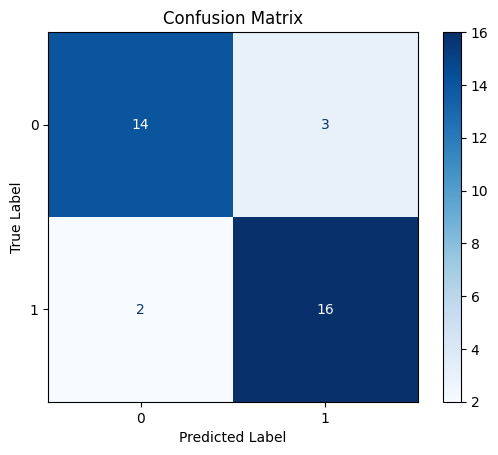

In [95]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred=model.predict(x_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

# Plot
disp.plot(cmap='Blues')  # You can also try cmap='viridis' or 'coolwarm'
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

**saving the model**

In [96]:
import joblib
# Save the trained model
joblib.dump(model,'decision_tree_model.pkl')

['decision_tree_model.pkl']

**resuing the model**

In [97]:
import joblib
# Load the model
loaded_model = joblib.load('decision_tree_model.pkl')

In [98]:
mat1=[
    [0, 0, 1, 0],
    [0, 0, 1, 1],
    [0, 0, 0, 1],
    [0, 0, 0, 0],
]
mat2=[
    [1, 1, 1,'not'],
    [2, 1, 1,'nand'],
    [2, 1, 2,'nand'],
    [1, 1, 0,'dff'],
]

In [99]:
# we are adding gate lables to a node features in previous column
# Sample mapping dictionary
label_map = {
    'and': 0,
    'or': 1,
    'nand': 2,
    'xor': 4,
    'nor': 3,
    'not': 5,
    'dff': 6,
    'reg':6,
    'srff':7,
    'tff':8,
    'jff':9,
    'add':10,
    'sub':11

}

mat2_numeric = [[*row[:3], label_map[row[3]]] for row in mat2]
mat2_numeric


[[1, 1, 1, 5], [2, 1, 1, 2], [2, 1, 2, 2], [1, 1, 0, 6]]

In [100]:
flat_mat1 = [item for row in mat1 for item in row]
flat_mat2 = [item for row in mat2_numeric for item in row]

# Pad them with zeros to match required size
flat_mat1 = flat_mat1[:49] + [0] * (49 - len(flat_mat1))
flat_mat2 = flat_mat2[:28] + [0] * (28 - len(flat_mat2))

# Combine into one list
et = flat_mat1 + flat_mat2

# Confirm the result
print(f"Length of et: {len(et)}")  # Should be 77
print(et)

Length of et: 77
[0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 5, 2, 1, 1, 2, 2, 1, 2, 2, 1, 1, 0, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [103]:
timing_config=[1,10,1,0.2,2,2.5]
input=et+timing_config
len(input)

83

In [107]:
input = np.array(input).reshape(1, -1)
output = model.predict(input)
prediction = int(output[0])

if prediction == 1:
    print("Timing violation detected in code for the provided timing configuration.")
else:
    print("No timing violation — design meets timing constraints.")

No timing violation — design meets timing constraints.
